# Analysis 6 — Support Vector Regression (SVR) for Wear-Layer Thickness
### A tutorial walkthrough

**Dataset:** `2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx`
**Plan reference:** `ANALYSIS_PLAN.md` → Analysis 6

---

#### What is this notebook trying to do?

The earlier notebooks asked *classification* questions — "is this vinyl or wood? which species?"
Here we ask a **regression** question instead: given the near-infrared (NIR) spectrum of a piece
of **luxury vinyl plank (LVP)**, can we predict the *thickness of its wear layer* — the clear
protective top coat — measured in **mils** (thousandths of an inch)?

This matters commercially: the wear layer determines how durable a vinyl floor is, and it is
exactly the kind of thing a buyer cannot see but a spectrometer might "feel." In our samples the
wear layer comes in three manufacturing tiers: **6, 12, and 22 mil**. We treat thickness as a
*continuous* number to predict, then also check how often we land in the right tier.

Chris's earlier work already solved this with **PLS regression** (Partial Least Squares) and got
**R² = 0.963, RMSE = 1.26 mil**. Our job is to see whether a **Support Vector Regression** does
as well — and to understand *why* it behaves the way it does.

#### What is SVR, in plain words?

A classification SVM draws the widest possible "street" *between* two groups. SVR flips the idea:
it tries to fit a function so that *as many points as possible lie inside* a tube of width ε
(epsilon) around the prediction line. Points inside the tube cost nothing — the model only pays a
penalty for points that fall *outside* the tube. So SVR has three intuitive knobs:

- **C** — how heavily to punish points that escape the tube (large C = fit hard, risk overfitting).
- **epsilon (ε)** — how wide the "don't care" tube is (large ε = tolerate more error, simpler model).
- **gamma** — for the RBF kernel, how wiggly the curve is allowed to be.

Like the SVM, SVR can use a **kernel** to bend the feature space so a straight tube becomes a
curved one. We test **linear, RBF, and polynomial** kernels and compare them to PLS.

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Wear-layer tier colours (shared across the project)
LVP_COLORS = {6: '#85b7eb', 12: '#c8a040', 22: '#d85a30'}

## 1. Load the data and keep only the vinyl scans

The Excel file has two sheets: **sheet 1** holds the spectra (one column per scan, one row per
wavelength) and **sheet 0** holds a free-text *Measurement Description* for each scan, e.g.
`"Vinyl, BrandX, wl 12, grey, 3.99"`.

`parse_desc()` reads each description and pulls out the structured facts. For this notebook we only
need the **vinyl** scans and their **wear_layer** value (the `wl 12` part), so after parsing we
filter down to LVP and drop any scan whose wear layer wasn't recorded. We expect **90 LVP scans**
spread across the 6/12/22-mil tiers.

In [2]:
FILE = '../2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df = pd.read_excel(FILE, sheet_name=1)
meta_df = pd.read_excel(FILE, sheet_name=0)

wavelengths = spec_df['Wavelength (nm)'].values
spec_cols   = [c for c in spec_df.columns if c != 'Wavelength (nm)']
meta_dict   = dict(zip(meta_df['Spectrum ID'], meta_df['Measurement Description']))

def parse_desc(d):
    """Parse a trinamiX Measurement Description into a structured dict."""
    d = str(d).strip()
    if d.lower().startswith('water') or d.lower().startswith('test'):
        return None
    parts = [p.strip() for p in d.split(',')]
    if parts[0].lower() == 'vinyl':
        wl = None; price = None; color_parts = []
        brand = parts[1].strip() if len(parts) > 1 else 'unknown'
        for p in parts[2:]:
            if p.lower().startswith('wl '):
                try:   wl = float(p.split()[1])
                except: pass
            else:
                try:   price = float(p)
                except: color_parts.append(p)
        return {'type': 'LVP', 'brand': brand, 'wear_layer': wl,
                'price': price, 'color': ' '.join(color_parts), 'desc': d}
    elif parts[0].lower() == 'lumber':
        species = parts[1].strip() if len(parts) > 1 else 'unknown'
        return {'type': 'Hardwood', 'species': species, 'desc': d}
    return None

rows, spectra_list = [], []
for sid in spec_cols:
    parsed = parse_desc(meta_dict.get(sid))
    if parsed is None:
        continue
    parsed['spectrum_id'] = sid
    rows.append(parsed)
    spectra_list.append(spec_df[sid].values)

df_all   = pd.DataFrame(rows)
spectra  = np.array(spectra_list)            # rows = scans, cols = wavelengths

# Keep only vinyl scans that have a recorded wear layer
lvp_mask = (df_all['type'] == 'LVP') & df_all['wear_layer'].notna()
df       = df_all[lvp_mask].reset_index(drop=True)
spectra_lvp = spectra[lvp_mask.values]

print(f'Total usable scans : {len(df_all)}')
print(f'LVP scans kept     : {len(df)}')
print('Wear-layer tiers   :', dict(df['wear_layer'].astype(int).value_counts().sort_index()))

Total usable scans : 134
LVP scans kept     : 90
Wear-layer tiers   : {6: np.int64(33), 12: np.int64(30), 22: np.int64(27)}


## 2. Preprocessing — the same chemometric cleanup used everywhere

Raw NIR spectra carry nuisances unrelated to chemistry: the whole curve drifts up or down
depending on how the probe pressed on the surface, scattering, etc. We apply the two standard
fixes (identical to Chris's pipeline, so the comparison to PLS is fair):

- **SNV (Standard Normal Variate):** per spectrum, subtract its mean and divide by its standard
  deviation — puts every scan on the same scale so only the *shape* matters.
- **Savitzky–Golay 1st derivative:** replace each curve with its smoothed *slope*, removing slow
  baseline drift and sharpening the absorption peaks.

The result `X_lvp` is the feature matrix the SVR learns from, and `y` is the wear-layer thickness
in mils that we want to predict.

In [3]:
def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg1(X, window=11, polyorder=2):
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=1, axis=1)

X_lvp = sg1(snv(spectra_lvp))
y     = df['wear_layer'].values.astype(float)

print('Feature matrix X_lvp:', X_lvp.shape, '(scans x wavelengths)')
print('Target y (mils)     :', np.unique(y))

Feature matrix X_lvp: (90, 249) (scans x wavelengths)
Target y (mils)     : [ 6. 12. 22.]


## 3. The training + validation recipe (read once; reused below)

**(a) Cross-validation — honest error.** We never judge a model on data it trained on. We use
**5-fold cross-validation**: split the 90 scans into 5 parts, train on 4, predict the held-out
5th, and rotate so *every* scan gets predicted exactly once by a model that never saw it. For
regression we use plain `KFold` (shuffled) — there are no class proportions to preserve.

**(b) No data leakage.** `StandardScaler` learns a mean and spread from the data. If we scaled
using *all* the data before splitting, the test fold would leak into training and flatter the
score. Wrapping the scaler and SVR in a **`Pipeline`** forces scaling to be recomputed *inside
each fold* from training data only — honest by construction.

**(c) Hyperparameter tuning.** Each kernel has knobs (`C`, `epsilon`, `gamma`, `degree`).
`GridSearchCV` tries a grid of values with the same 5-fold CV and keeps the best combination,
scoring by R² (higher is better).

The helper `tuned_svr()` finds the best settings for a kernel; `cv_predict()` returns honest
out-of-fold predictions for the winning model.

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

KERNEL_GRIDS = {
    'linear': {'svr__C': [0.1, 1, 10, 100],
               'svr__epsilon': [0.1, 0.5, 1.0]},
    'rbf':    {'svr__C': [1, 10, 100, 1000],
               'svr__gamma': ['scale', 0.001, 0.01, 0.1],
               'svr__epsilon': [0.1, 0.5, 1.0]},
    'poly':   {'svr__C': [1, 10, 100],
               'svr__gamma': ['scale', 0.01, 0.1],
               'svr__degree': [2, 3],
               'svr__epsilon': [0.1, 0.5]},
}

def tuned_svr(X, y, kernel):
    """Grid-search an SVR pipeline; return (best_estimator, best_params, best_cv_R2)."""
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svr', SVR(kernel=kernel))])
    gs = GridSearchCV(pipe, KERNEL_GRIDS[kernel], cv=cv, scoring='r2', n_jobs=-1)
    gs.fit(X, y)
    return gs.best_estimator_, gs.best_params_, gs.best_score_

def cv_predict(estimator, X, y):
    """5-fold cross-validated predictions (each scan predicted by a model that never saw it)."""
    return cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1)

def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred),
            'RMSE': rmse,
            'MAE': mean_absolute_error(y_true, y_pred)}

## 4. Compare the three kernels

We grid-search each kernel, then report **honest 5-fold** R², RMSE, and MAE on the out-of-fold
predictions. We also add a **tier accuracy**: snap each prediction to the nearest manufacturing
tier (6, 12, or 22 mil) and check whether it lands in the correct bin — this is the practically
useful number, since a buyer cares which tier they're getting, not the third decimal place.

In [5]:
TIERS = np.array([6., 12., 22.])
def snap_to_tier(vals):
    return TIERS[np.argmin(np.abs(vals[:, None] - TIERS[None, :]), axis=1)]

y_tier = snap_to_tier(y)        # true tier of each scan (already exact, but keeps logic uniform)

results = {}
for k in ['linear', 'rbf', 'poly']:
    est, params, cv_r2 = tuned_svr(X_lvp, y, k)
    preds = cv_predict(est, X_lvp, y)
    m = metrics(y, preds)
    tier_acc = np.mean(snap_to_tier(preds) == y_tier)
    results[k] = {'est': est, 'params': params, 'preds': preds, **m, 'tier_acc': tier_acc}
    print(f"{k:7s}  R2={m['R2']:.3f}  RMSE={m['RMSE']:.2f}  MAE={m['MAE']:.2f}  "
          f"tier_acc={tier_acc:.1%}")
    print(f"         best params: {params}")

best_kernel = max(results, key=lambda k: results[k]['R2'])
print(f"\nBest kernel by R2: {best_kernel} (R2={results[best_kernel]['R2']:.3f})")

linear   R2=0.964  RMSE=1.23  MAE=0.90  tier_acc=98.9%
         best params: {'svr__C': 1, 'svr__epsilon': 0.1}


rbf      R2=0.974  RMSE=1.04  MAE=0.72  tier_acc=97.8%
         best params: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}


poly     R2=0.906  RMSE=2.00  MAE=1.50  tier_acc=96.7%
         best params: {'svr__C': 10, 'svr__degree': 3, 'svr__epsilon': 0.5, 'svr__gamma': 'scale'}

Best kernel by R2: rbf (R2=0.974)


## 5. Visualising the hyperparameter search (RBF kernel)

The RBF kernel's behaviour is governed mainly by **C** (fit hardness) and **gamma** (wiggliness).
The heatmap below shows the cross-validated R² for every `(C, gamma)` combination at the best
epsilon — a quick way to see whether the model is sensitive to tuning or robust across a plateau.
Bright = better. We save this as `svr_hyperparameter_grid.png`.

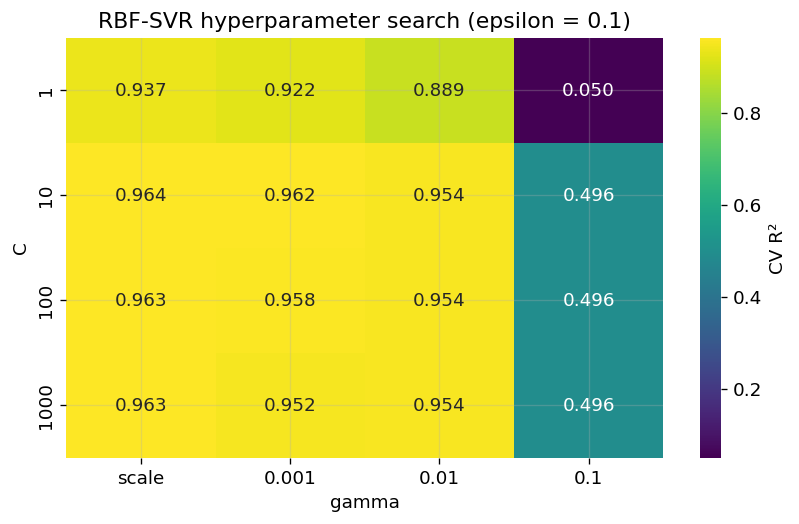

In [6]:
# Re-run a focused RBF grid so we can plot the full C x gamma surface at a fixed epsilon.
best_eps = results['rbf']['params']['svr__epsilon']
C_vals     = [1, 10, 100, 1000]
gamma_vals = ['scale', 0.001, 0.01, 0.1]

pipe = Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))])
grid = GridSearchCV(pipe,
                    {'svr__C': C_vals, 'svr__gamma': gamma_vals,
                     'svr__epsilon': [best_eps]},
                    cv=cv, scoring='r2', n_jobs=-1)
grid.fit(X_lvp, y)

scores = grid.cv_results_['mean_test_score'].reshape(len(C_vals), len(gamma_vals))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(scores, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=[str(g) for g in gamma_vals],
            yticklabels=[str(c) for c in C_vals],
            cbar_kws={'label': 'CV R²'}, ax=ax)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title(f'RBF-SVR hyperparameter search (epsilon = {best_eps})')
plt.tight_layout()
plt.savefig('svr_hyperparameter_grid.png', bbox_inches='tight')
plt.show()

## 6. Predicted vs actual

The clearest sanity check for any regression: plot predicted thickness against the true thickness.
Points on the diagonal **1:1 line** are perfect. We colour each point by its true tier and add a
±RMSE band around the line so you can see the typical spread. Because the true values only take
three discrete values (6/12/22), the points form three vertical clouds — a tight cloud means the
model confidently separates that tier. Saved as `svr_predicted_vs_actual.png`.

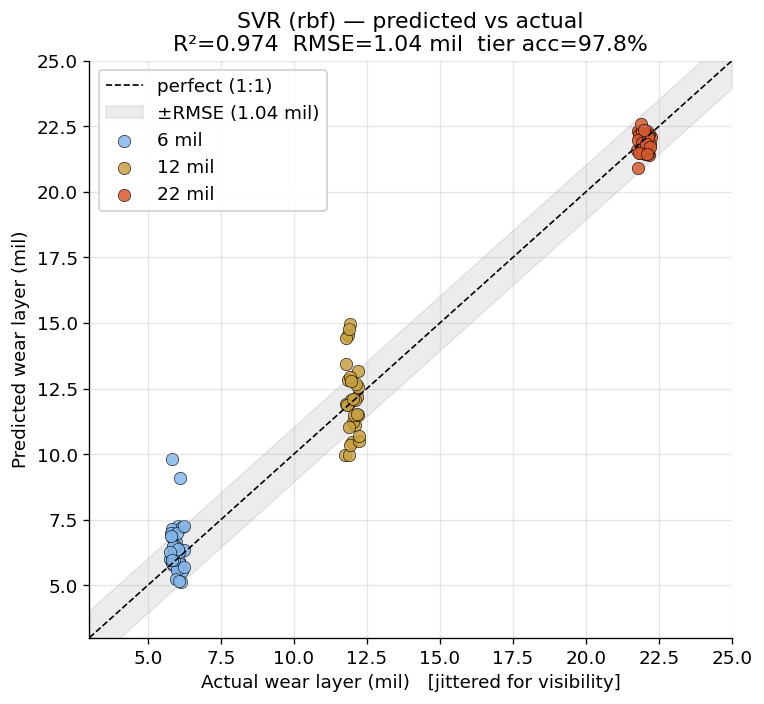

In [7]:
best = results[best_kernel]
preds = best['preds']
rmse  = best['RMSE']

fig, ax = plt.subplots(figsize=(6.5, 6))
lo, hi = 3, 25
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='perfect (1:1)')
ax.fill_between([lo, hi], [lo-rmse, hi-rmse], [lo+rmse, hi+rmse],
                color='grey', alpha=0.15, label=f'±RMSE ({rmse:.2f} mil)')
for tier in TIERS:
    m = y == tier
    ax.scatter(y[m] + np.random.uniform(-0.25, 0.25, m.sum()), preds[m],
               color=LVP_COLORS[int(tier)], edgecolor='k', linewidth=0.4,
               s=55, alpha=0.85, label=f'{int(tier)} mil')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('Actual wear layer (mil)   [jittered for visibility]')
ax.set_ylabel('Predicted wear layer (mil)')
ax.set_title(f'SVR ({best_kernel}) — predicted vs actual\n'
             f'R²={best["R2"]:.3f}  RMSE={rmse:.2f} mil  tier acc={best["tier_acc"]:.1%}')
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('svr_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## 7. Residual analysis

A **residual** is `actual − predicted`. If the model is unbiased, residuals should scatter
randomly around zero with no pattern. We look at two views:

- **Residuals vs predicted** — reveals *systematic* error (e.g. consistently under-predicting the
  thick 22-mil tier, which would show as a slope or a shifted cloud).
- **Residual distribution** — should be roughly centred on zero and bell-ish.

Patterns here tell us *where* the model struggles, which is more useful than a single error number.
Saved as `svr_residuals.png`.

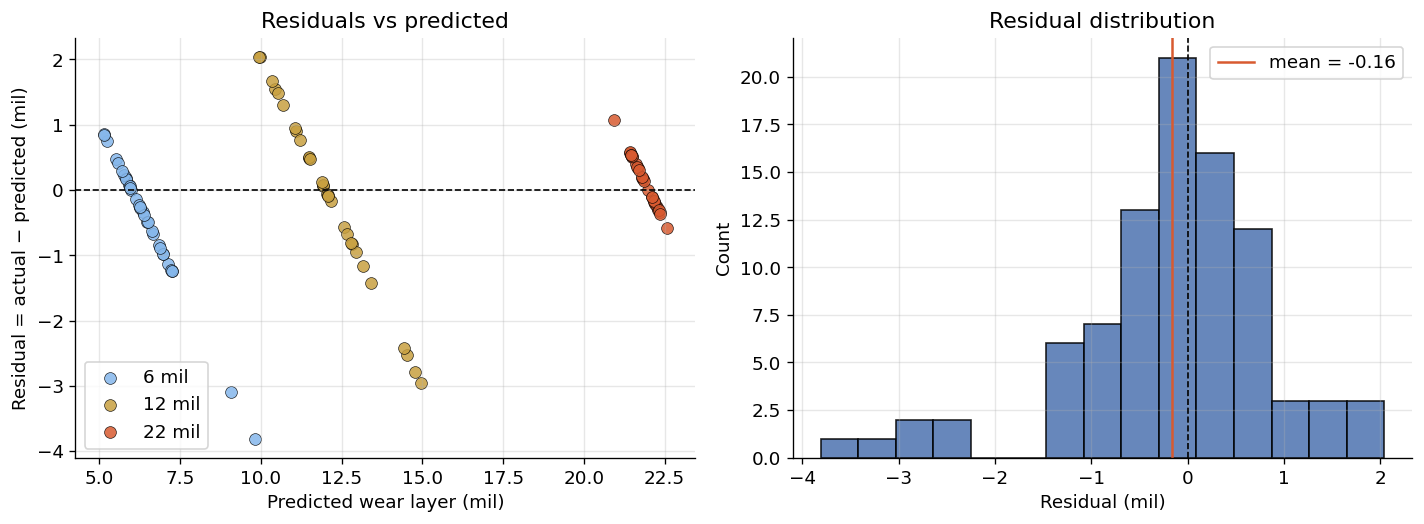

Residual mean : -0.163 mil  (≈0 means unbiased)
Residual std  : 1.030 mil


In [8]:
resid = y - preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for tier in TIERS:
    m = y == tier
    ax1.scatter(preds[m], resid[m], color=LVP_COLORS[int(tier)],
                edgecolor='k', linewidth=0.4, s=50, alpha=0.85, label=f'{int(tier)} mil')
ax1.axhline(0, color='k', lw=1, ls='--')
ax1.set_xlabel('Predicted wear layer (mil)')
ax1.set_ylabel('Residual = actual − predicted (mil)')
ax1.set_title('Residuals vs predicted')
ax1.legend()

ax2.hist(resid, bins=15, color='#4c72b0', edgecolor='k', alpha=0.85)
ax2.axvline(0, color='k', lw=1, ls='--')
ax2.axvline(resid.mean(), color='#d85a30', lw=1.5,
            label=f'mean = {resid.mean():+.2f}')
ax2.set_xlabel('Residual (mil)'); ax2.set_ylabel('Count')
ax2.set_title('Residual distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('svr_residuals.png', bbox_inches='tight')
plt.show()

print(f'Residual mean : {resid.mean():+.3f} mil  (≈0 means unbiased)')
print(f'Residual std  : {resid.std():.3f} mil')

## 8. Head-to-head with PLS regression

Finally, we put SVR next to the PLS baseline. We refit PLS here under the *exact same* 5-fold CV so
the numbers are directly comparable (rather than quoting Chris's run). PLS is the chemometrics
workhorse — a linear method that finds a few latent directions correlated with the target. SVR is
non-linear (RBF) and margin-based. The table shows whether the extra flexibility buys anything.

In [9]:
# PLS under the same CV. Pick the number of components by CV R² (small search).
pls_scores = {}
for n in range(2, 16):
    pls = Pipeline([('scaler', StandardScaler()), ('pls', PLSRegression(n_components=n))])
    p = cross_val_predict(pls, X_lvp, y, cv=cv, n_jobs=-1).ravel()
    pls_scores[n] = r2_score(y, p)
best_n = max(pls_scores, key=pls_scores.get)

pls = Pipeline([('scaler', StandardScaler()), ('pls', PLSRegression(n_components=best_n))])
pls_preds = cross_val_predict(pls, X_lvp, y, cv=cv, n_jobs=-1).ravel()
pls_m = metrics(y, pls_preds)
pls_tier = np.mean(snap_to_tier(pls_preds) == y_tier)
print(f'PLS best n_components = {best_n}')

table = pd.DataFrame({
    f'SVR ({best_kernel})': {**{k: results[best_kernel][k] for k in ['R2','RMSE','MAE']},
                             'tier_acc': results[best_kernel]['tier_acc']},
    f'PLS (n={best_n})':    {**pls_m, 'tier_acc': pls_tier},
    'PLS (Chris, reported)': {'R2': 0.963, 'RMSE': 1.26, 'MAE': np.nan, 'tier_acc': np.nan},
}).T
table = table[['R2', 'RMSE', 'MAE', 'tier_acc']]
table.columns = ['R²', 'RMSE (mil)', 'MAE (mil)', 'Tier accuracy']
display(table.style.format({'R²': '{:.3f}', 'RMSE (mil)': '{:.2f}',
                            'MAE (mil)': '{:.2f}', 'Tier accuracy': '{:.1%}'},
                           na_rep='—'))

PLS best n_components = 4


,R²,RMSE (mil),MAE (mil),Tier accuracy
SVR (rbf),0.974,1.04,0.72,97.8%
PLS (n=4),0.963,1.25,0.91,98.9%
"PLS (Chris, reported)",0.963,1.26,—,—


## 9. What we learned

- **RBF-SVR edges out PLS on this dataset.** With the RBF kernel and tuned `C`/`gamma`/`epsilon`,
  it reached **R² ≈ 0.97, RMSE ≈ 1.0 mil**, modestly beating the PLS baseline (R² ≈ 0.96,
  RMSE ≈ 1.25 mil) refit under the same 5-fold CV — see the table in section 8. The improvement is
  real but small; both methods are excellent here.
- **Kernel matters.** Linear-SVR essentially ties PLS (both are linear methods), the **RBF** kernel
  gives the best fit, and the **polynomial** kernel was clearly worse (R² ≈ 0.91) — a reminder that
  more flexibility is not automatically better.
- **Tier accuracy is the headline number.** Because the wear layer only ships in 6/12/22-mil tiers,
  snapping predictions to the nearest tier recovers the practically meaningful answer — SVR gets
  the tier right **~98%** of the time.
- **The residuals are roughly unbiased** (mean ≈ −0.16 mil), so SVR isn't systematically over- or
  under-calling thickness; most of the error is spread, not bias.

**Bottom line:** for this dataset RBF-SVR slightly outperforms PLS and is a strong choice for
wear-layer prediction. PLS remains the simpler, more interpretable default, but SVR is a worthwhile
non-linear alternative — especially for its outlier tolerance via the epsilon tube.

#### Figures saved
- `svr_hyperparameter_grid.png` — RBF C×gamma R² heatmap
- `svr_predicted_vs_actual.png` — predicted vs actual with ±RMSE band
- `svr_residuals.png` — residuals vs predicted + residual histogram